<a href="https://colab.research.google.com/github/PabloDuranLopez/Miprogresionypraticas/blob/main/PoissonDC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson,skellam
from scipy.optimize import minimize

In [123]:
df=pd.read_csv("liga_mx_historica.csv")

  temporada    torneo  jornada  fecha   hora                  local  \
0   2010/11  Apertura        1    NaN  20:10      Estudiantes Tecos   
1   2010/11  Apertura        1    NaN  17:00       Jaguares Chiapas   
2   2010/11  Apertura        1    NaN  19:00             CF Pachuca   
3   2010/11  Apertura        1    NaN    NaN            UANL Tigres   
4   2010/11  Apertura        1    NaN    NaN  Deportivo Guadalajara   
5   2010/11  Apertura        1    NaN  20:45          Club San Luis   
6   2010/11  Apertura        1    NaN  21:00                Atlante   
7   2010/11  Apertura        1    NaN  12:00       Monarcas Morelia   
8   2010/11  Apertura        1    NaN    NaN             Pumas UNAM   
9   2010/11  Apertura        2    NaN  20:10            Club Necaxa   

           visitante  goles_local  goles_visitante  
0          Cruz Azul            0                3  
1        Club Necaxa            1                1  
2         CF América            3                0  
3     

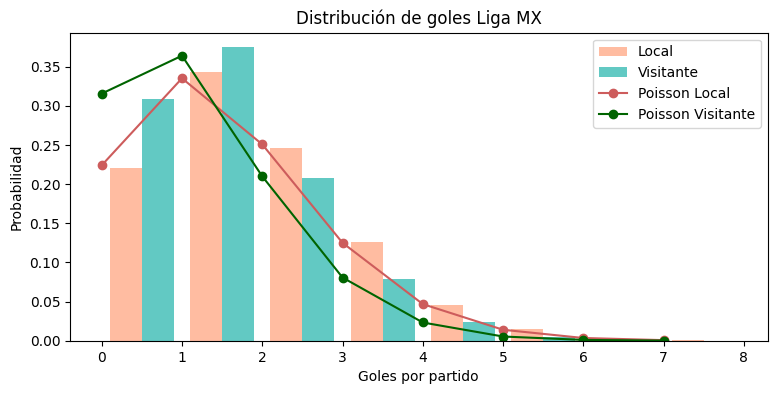

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  goles   No. Observations:                 9974
Model:                            GLM   Df Residuals:                     9918
Model Family:                 Poisson   Df Model:                           55
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -14281.
Date:                Fri, 24 Jul 2026   Deviance:                       10862.
Time:                        06:01:17   Pearson chi2:                 9.31e+03
No. Iterations:                     5   Pseudo R-squ. (CS):            0.07215
Covariance Type:            nonrobust                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

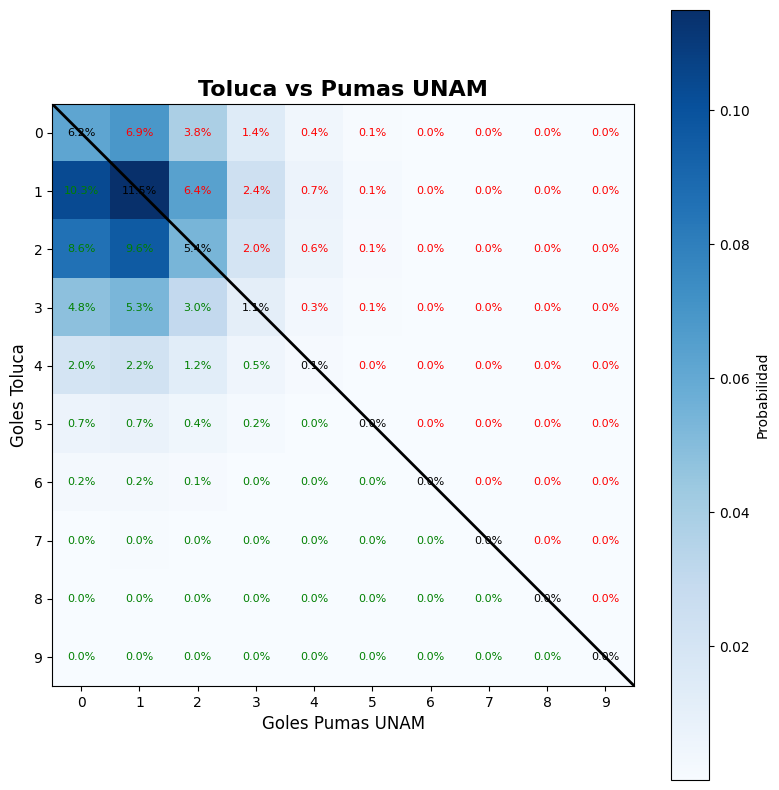

None
     Toluca   empate  Pumas UNAM  Momio Toluca   Momio empate  \
0  0.502809  0.24272    0.254461          -101            312   

   Momio Pumas UNAM  
0               293  


In [118]:

#%%
print(df.head(10))
print(df.shape)
print(df.isnull().sum())
print(df.temporada.nunique())
#%%
df["fecha"] = pd.to_datetime(
    df["fecha"],
    format="%a %b %d %Y"
)
df = df.sort_values("fecha").reset_index(drop=True)

#%%
print(df.local.nunique())
print("\n")
#%%
df.info()
#%%
df.describe()
#%%
equipos = sorted(set(df.local) | set(df.visitante))

print(equipos)
#%%
loc=df.groupby("local")["goles_local"].mean()
vis=df.groupby("visitante")["goles_visitante"].mean()
gol_mean=pd.concat([loc,vis], axis=1)
print(gol_mean.head(10))
#%%
gol_mean["ventaja_local"]=gol_mean["goles_local"]-gol_mean["goles_visitante"]
print(gol_mean)
print("\n")
#%%
lambda_visitante=df["goles_local"].mean()-df["goles_visitante"].mean()
print(f"Ventaja de local: {lambda_visitante}")
#%%

media = df[["goles_local", "goles_visitante"]].mean()
poisson_pred = np.column_stack([
    [poisson.pmf(i, media["goles_local"]) for i in range(8)],
    [poisson.pmf(i, media["goles_visitante"]) for i in range(8)]
])
#%%


fig, ax = plt.subplots(figsize=(9,4))

plt.hist(
    df[['goles_local','goles_visitante']].values,
    bins=range(9),
    density=True,
    alpha=0.7,
    label=['Local','Visitante'],
    color=["#FFA07A","#20B2AA"]
)

plt.plot(
    np.arange(8),
    poisson_pred[:,0],
    '-o',
    color='#CD5C5C',
    label='Poisson Local'
)

plt.plot(
    np.arange(8),
    poisson_pred[:,1],
    '-o',
    color='#006400',
    label='Poisson Visitante'
)

plt.xlabel("Goles por partido")
plt.ylabel("Probabilidad")
plt.title("Distribución de goles Liga MX")
plt.legend()

plt.show()
#%%
import statsmodels.api as sm
import statsmodels.formula.api as smf

model_gol=pd.concat([df[['local','visitante','goles_local']].assign(home=1).rename(
            columns={'local':'equipo', 'visitante':'oponente','goles_local':'goles'}),
           df[['local','visitante','goles_visitante']].assign(home=0).rename(
            columns={'visitante':'equipo', 'local':'oponente','goles_visitante':'goles'})])

poisson_model = smf.glm(formula="goles ~ home + equipo + oponente", data=model_gol,
                        family=sm.families.Poisson()).fit()

print(poisson_model.summary())

#%%
nuevo = pd.DataFrame({
    "equipo":["Deportivo Toluca"],
    "oponente":["Pumas UNAM"],
    "home":[1]
})

print(poisson_model.predict(nuevo))
#%%

def simular_partido(modelo, local, visitante, goles_max=10):
    loc= pd.DataFrame({"equipo": [local],"oponente":[visitante],"home":[1]})
    vis=pd.DataFrame({"equipo":visitante, "oponente":local, "home":[0]})
    goles_local=modelo.predict(loc)
    goles_visitante=modelo.predict(vis)
    marcadores=[[poisson.pmf(i,goles) for i in range(0,goles_max)] for goles in [goles_local,goles_visitante]]
    return (np.outer(np.array(marcadores[0]),np.array(marcadores[1])))
#%%
def score_matrix(prob,
                      equipo_local="Local",
                      equipo_visitante="Visitante",
                      mostrar_porcentaje=True,
                      cmap="Blues"):

    n = prob.shape[0]

    fig, ax = plt.subplots(figsize=(8,8))

    # Heatmap
    im = ax.imshow(prob, cmap=cmap)

    # Barra de color
    cbar = plt.colorbar(im)
    cbar.set_label("Probabilidad")

    # Diagonal
    ax.plot([-0.5,n-0.5],[-0.5,n-0.5],
            color="black",
            linewidth=2)

    # Texto en cada celda
    for i in range(n):
        for j in range(n):

            if i > j:
                color = "green"
            elif i == j:
                color = "black"
            else:
                color = "red"

            if mostrar_porcentaje:
                texto = f"{100*prob[i,j]:.1f}%"
            else:
                texto = f"{prob[i,j]:.3f}"

            ax.text(j,
                    i,
                    texto,
                    ha="center",
                    va="center",
                    color=color,
                    fontsize=8)

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))

    ax.set_xlabel(f"Goles {equipo_visitante}", fontsize=12)
    ax.set_ylabel(f"Goles {equipo_local}", fontsize=12)

    ax.set_title(f"{equipo_local} vs {equipo_visitante}",
                 fontsize=16,
                 fontweight="bold")

    plt.tight_layout()
    plt.show()
plt.show()

#%%
def prob_a_american(proba_individual):

    decimal = 1/proba_individual

    if decimal >= 2:
        return round((decimal-1)*100)
    else:
        return round(-100/(decimal-1))
#%%

def win_prob(prob, local="loc", visitante='vis'):
    prob_local = np.tril(prob, -1).sum()
    prob_empate = np.trace(prob)
    prob_visitante = np.triu(prob, 1).sum()
    diccionario={local:prob_local,"empate":prob_empate,visitante:prob_visitante}
    tabla=pd.DataFrame([diccionario])
    tabla[f"Momio { local}"]=tabla[local].apply(prob_a_american)
    tabla[" Momio empate"]=tabla["empate"].apply(prob_a_american)
    tabla[f"Momio {visitante}"]=tabla[visitante].apply(prob_a_american)
    return tabla

#%%
partido_random=simular_partido(poisson_model, "Deportivo Toluca", "Pumas UNAM", 10)
print(score_matrix(partido_random, "Toluca", "Pumas UNAM"))
probas=win_prob(partido_random, "Toluca", "Pumas UNAM")
print(probas)


In [119]:
#Dixon-Coles

In [120]:
def rhodixon(x,y,lamb,mu,phi):
      if x==0 and y==0:
        return 1-lamb*mu*phi
      elif x==0 and y==1:
        return 1+lamb*phi
      elif x==1 and y==0:
        return 1+mu*phi
      elif x==1 and y==1:
        return 1-phi
      else:
        return 1

In [129]:
def Dixon_coles(df):
    equipos = np.sort(df["local"].unique())
    n = len(equipos)

    indice = {e: i for i, e in enumerate(equipos)}

    local_idx = df["local"].map(indice).to_numpy()
    visitante_idx = df["visitante"].map(indice).to_numpy()

    goles_local = df["goles_local"].to_numpy()
    goles_visitante = df["goles_visitante"].to_numpy()


    parametros = np.concatenate([
        np.random.uniform(0,0.5,n),      # ataque
        np.random.uniform(-0.5,0,n),     # defensa
        np.array([0.20,-0.05])           # gamma, rho
    ])



    def estimar_parametros(param):

        ataque = param[:n]
        defensa = param[n:2*n]

        gamma = param[-2]
        rho = param[-1]


        lambda_ = np.exp(
            ataque[local_idx] +
            defensa[visitante_idx] +
            gamma
        )

        mu = np.exp(
            ataque[visitante_idx] +
            defensa[local_idx]
        )



        tau = np.ones(len(df))

        m00 = (goles_local==0) & (goles_visitante==0)
        m01 = (goles_local==0) & (goles_visitante==1)
        m10 = (goles_local==1) & (goles_visitante==0)
        m11 = (goles_local==1) & (goles_visitante==1)

        tau[m00] = 1 - lambda_[m00]*mu[m00]*rho
        tau[m01] = 1 + lambda_[m01]*rho
        tau[m10] = 1 + mu[m10]*rho
        tau[m11] = 1 - rho

        tau = np.maximum(tau,1e-12)

        log_like = np.sum(
            np.log(tau)
            + poisson.logpmf(goles_local,lambda_)
            + poisson.logpmf(goles_visitante,mu)
        )

        return -log_like



    def restriccion(param):
        return np.sum(param[:n])

    cons = ({
        "type":"eq",
        "fun":restriccion
    })

    bounds = [(-4,4)]*(2*n)
    bounds += [(-1,1),(-0.2,0.2)]

    opt = minimize(
        estimar_parametros,
        parametros,
        method="SLSQP",
        constraints=cons,
        bounds=bounds,
        options={
            "disp":True,
            "maxiter":1000
        }
    )

    ataque = dict(zip(equipos,opt.x[:n]))
    defensa = dict(zip(equipos,opt.x[n:2*n]))

    return {
        "ataque":ataque,
        "defensa":defensa,
        "gamma":opt.x[-2],
        "rho":opt.x[-1],
        "logLik":-opt.fun,
        "resultado":opt
    }






In [130]:
a=Dixon_coles(df)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 14275.364232447486
            Iterations: 67
            Function evaluations: 4108
            Gradient evaluations: 67


In [132]:
xd=pd.DataFrame([a])

In [133]:
xd

,ataque,defensa,gamma,rho,logLik,resultado
0,"{'Atlante': 0.0002939719262532026, 'Atlas Guad...","{'Atlante': 0.3093568156976302, 'Atlas Guadala...",0.259189,-0.060587,-14275.364232,"{'x': [0.0002939719262532026, -0.1134955961794..."
